### 多分类的建模

#### 导包

In [3]:
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import tree
import graphviz

#### 加载数据

In [4]:
X,y = datasets.load_iris(return_X_y = True) # 150个样本
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 1024)
X_train.shape

(120, 4)

In [5]:
y_train

array([1, 2, 2, 2, 1, 1, 1, 1, 0, 1, 1, 1, 0, 2, 0, 2, 2, 0, 1, 2, 2, 2,
       0, 0, 1, 2, 2, 1, 2, 1, 2, 2, 1, 1, 2, 0, 0, 2, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 2, 2, 2, 2, 1, 0, 1, 0, 2, 2, 0, 2, 2, 2, 1,
       2, 1, 0, 2, 0, 0, 2, 1, 2, 1, 0, 0, 1, 0, 2, 1, 0, 0, 2, 0, 2, 2,
       1, 0, 1, 2, 0, 1, 0, 1, 1, 2, 0, 0, 0, 0, 0, 2, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 2, 1, 2, 1, 2])

#### 算法建模

In [6]:
# 多分类问题，不是+1、-1
# 类别0,1,2
ada = AdaBoostClassifier(n_estimators=3,algorithm='SAMME',learning_rate=1.0)
ada.fit(X_train,y_train) #算法，工作：从X_train---y_train寻找规律
y_ = ada.predict(X_test)
proba_ = ada.predict_proba(X_test)
accuracy = ada.score(X_test,y_test)
print('--------------------算法准确率：',accuracy)
display(y_,proba_)

--------------------算法准确率： 0.9666666666666667


array([1, 0, 2, 2, 0, 0, 1, 2, 1, 0, 0, 0, 1, 2, 1, 0, 1, 0, 1, 0, 2, 0,
       1, 0, 2, 1, 2, 2, 2, 2])

array([[0.33156225, 0.38881125, 0.2796265 ],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.2783866 , 0.31174493, 0.40986847],
       [0.2783866 , 0.31174493, 0.40986847],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.33156225, 0.38881125, 0.2796265 ],
       [0.2783866 , 0.31174493, 0.40986847],
       [0.33156225, 0.38881125, 0.2796265 ],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.33156225, 0.38881125, 0.2796265 ],
       [0.2783866 , 0.31174493, 0.40986847],
       [0.2796265 , 0.38881125, 0.33156225],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.33156225, 0.38881125, 0.2796265 ],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.2796265 , 0.38881125, 0.33156225],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.2783866 , 0.31174493, 0.40986847],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.

In [7]:
proba_.argmax(axis=1)

array([1, 0, 2, 2, 0, 0, 1, 2, 1, 0, 0, 0, 1, 2, 1, 0, 1, 0, 1, 0, 2, 0,
       1, 0, 2, 1, 2, 2, 2, 2], dtype=int64)

#### 可视化

In [13]:
iris = datasets.load_iris()
fn = iris['feature_names']
fn

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

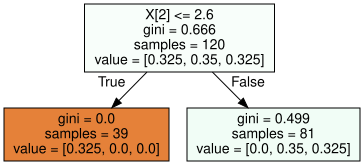

In [26]:
# 这棵树，简单的树，树的深度：1
# Adaboosting里面都是简单的树
dot_data = tree.export_graphviz(ada[0],filled=True)
graphviz.Source(dot_data)

In [27]:
0 * 39/120 + 0.499 * 81/120

0.336825

In [9]:
ada[0]

DecisionTreeClassifier(max_depth=1, random_state=794409994)

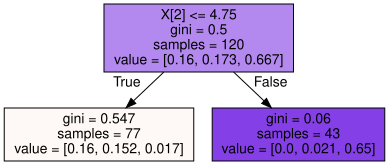

In [10]:
# 这棵树，简单的树，树的深度：1
# Adaboosting里面都是简单的树
dot_data = tree.export_graphviz(ada[1],filled=True)
graphviz.Source(dot_data)

In [36]:
0.547 * 77/120 + 0.06 * 43/120

0.37249166666666667

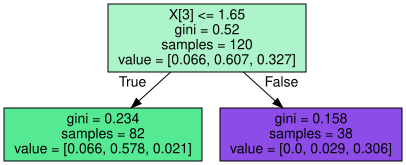

In [11]:
# 这棵树，简单的树，树的深度：1
# Adaboosting里面都是简单的树
dot_data = tree.export_graphviz(ada[2],filled=True)
graphviz.Source(dot_data)

### 构建第一棵树

#### gini系数计算

In [18]:
w1 = np.full(shape = 120,fill_value=1/120)

gini = 0
for i in range(3):
    cond = y_train == i
    p = w1[cond].sum() # 某个类别的概率
    gini += p * (1 -p)
print(np.round(gini,3))

0.666


In [20]:
w1 = np.full(shape = 120,fill_value=1/120)

gini = 1
for i in range(3):
    cond = y_train == i
    p = w1[cond].sum() # 某个类别的概率
    print(p)
    gini -= p**2
print(np.round(gini,3))

0.3250000000000002
0.35000000000000003
0.3250000000000002
0.666


#### 拆分条件计算

In [28]:
best_split = {}
lower_gini = 1
# 4个特征，选哪一个？每一个特征，是不是，都要进行计算
cols = X_train.shape[1]
samples = X_train.shape[0]
for col in range(cols):
    for i in range(samples):
        X = X_train[:,col].copy() # 无序
        X.sort()
        split = X[i:i+2].mean()
        cond = X_train[:,col] < split
        left = y_train[cond]
        right = y_train[~cond]
        left_w1 = w1[cond]/w1[cond].sum()
        right_w1 = w1[~cond]/w1[~cond].sum()
        gini_left = 1
        gini_right = 1
        for target in np.unique(y_train):# 0,1,2
            cond1 = left == target
            p1 = left_w1[cond1].sum() # 左边中，某个类别的概率
            gini_left -= p1**2
            cond2 = right == target
            p2 = right_w1[cond2].sum() # 右边分组中，某个类别的概率
            gini_right -= p2**2
        # 计算划分后整体的gini系数 left + right
        left_p = w1[cond].sum()
        right_p = 1 - left_p
        gini = left_p * np.round(gini_left,3) + right_p * np.round(gini_right,3)
        if gini < lower_gini:
            lower_gini = gini
            best_split.clear()
            best_split['X[%d]'%(col)] = np.round(split,2)
print(lower_gini,best_split)

0.33682499999999993 {'X[2]': 2.6}


In [ ]:
# 前提：每个样本权重一样
# w1[cond].sum   和 cond.sum()/cond.size 一样 嘛 

#### 误差率计算

In [29]:
# 计算误差率
y1_ = ada[0].predict(X_train) #预测结果
print(y1_)
e1 = ((y_train != y1_)).mean()#误差
print('第一棵树误差率是：',e1)
print('算法的误差是：',ada.estimator_errors_)

[1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0
 1 0 1 0 1 0 1 1 1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1
 1 1 0 0 1 0 1 1 0 0 1 0 1 1 1 0 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 1 0 0
 1 1 0 1 1 1 1 1 1]
第一棵树误差率是： 0.325
算法的误差是： [0.325      0.18993352 0.1160323 ]


In [30]:
# 计算误差率
y1_ = ada[0].predict(X_train) #预测结果
print(y1_)
cond = y_train != y1_#误差
e1 = w1[cond].sum()
print('第一棵树误差率是：',e1)
print('算法的误差是：',ada.estimator_errors_)

[1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0
 1 0 1 0 1 0 1 1 1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1
 1 1 0 0 1 0 1 1 0 0 1 0 1 1 1 0 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 1 0 0
 1 1 0 1 1 1 1 1 1]
第一棵树误差率是： 0.3250000000000002
算法的误差是： [0.325      0.18993352 0.1160323 ]


#### 弱分类器的权重

In [31]:
learning_rate = 1.0
num = 3 # 三分类
a1 = learning_rate * (np.log((1-e1)/e1) + np.log(num - 1))
print('手动计算算法权重是：',a1)

print('算法返回的分类器权重是：',ada.estimator_weights_)

手动计算算法权重是： 1.424034689102737
算法返回的分类器权重是： [1.42403469 2.14358936 2.72369906]


#### 样本权重更新

In [32]:
# 更新样本的权重
w2 = w1 * np.exp(a1 * (y_train != y1_))
w2 /= w2.sum()
w2

array([0.00411523, 0.01709402, 0.01709402, 0.01709402, 0.00411523,
       0.00411523, 0.00411523, 0.00411523, 0.00411523, 0.00411523,
       0.00411523, 0.00411523, 0.00411523, 0.01709402, 0.00411523,
       0.01709402, 0.01709402, 0.00411523, 0.00411523, 0.01709402,
       0.01709402, 0.01709402, 0.00411523, 0.00411523, 0.00411523,
       0.01709402, 0.01709402, 0.00411523, 0.01709402, 0.00411523,
       0.01709402, 0.01709402, 0.00411523, 0.00411523, 0.01709402,
       0.00411523, 0.00411523, 0.01709402, 0.00411523, 0.00411523,
       0.00411523, 0.00411523, 0.00411523, 0.00411523, 0.00411523,
       0.00411523, 0.00411523, 0.00411523, 0.00411523, 0.00411523,
       0.00411523, 0.01709402, 0.01709402, 0.01709402, 0.01709402,
       0.00411523, 0.00411523, 0.00411523, 0.00411523, 0.01709402,
       0.01709402, 0.00411523, 0.01709402, 0.01709402, 0.01709402,
       0.00411523, 0.01709402, 0.00411523, 0.00411523, 0.01709402,
       0.00411523, 0.00411523, 0.01709402, 0.00411523, 0.01709

### 构建第二棵树

#### gini系数计算

In [34]:
gini = 1
for i in range(3):
    cond = y_train == i
    p = w2[cond].sum() # 某个类别的概率
#     print(p)
    gini -= p**2
print(np.round(gini,3))

0.5


#### 拆分条件

In [35]:
best_split = {}
lower_gini = 1
# 4个特征，选哪一个？每一个特征，是不是，都要进行计算
cols = X_train.shape[1]
samples = X_train.shape[0]
for col in range(cols):
    for i in range(samples):
        X = X_train[:,col].copy() # 无序
        X.sort()
        split = X[i:i+2].mean()
        cond = X_train[:,col] < split
        left = y_train[cond]
        right = y_train[~cond]
        left_w2 = w2[cond]/w2[cond].sum()
        right_w2 = w2[~cond]/w2[~cond].sum()
        gini_left = 1
        gini_right = 1
        for target in np.unique(y_train):# 0,1,2
            cond1 = left == target
            p1 = left_w2[cond1].sum() # 左边中，某个类别的概率
            gini_left -= p1**2
            cond2 = right == target
            p2 = right_w2[cond2].sum() # 右边分组中，某个类别的概率
            gini_right -= p2**2
        # 计算划分后整体的gini系数 left + right
        left_p = w2[cond].sum()
        right_p = 1 - left_p
        gini = left_p * np.round(gini_left,3) + right_p * np.round(gini_right,3)
        if gini < lower_gini:
            lower_gini = gini
            best_split.clear()
            best_split['X[%d]'%(col)] = np.round(split,2)
print(lower_gini,best_split)

0.22063754352643244 {'X[2]': 4.75}


In [41]:
cond = X_train[:,2] <= 4.75
p1 = w2[cond].sum()
p2 = 1 - p1
print(p1,p2)
p1 * 0.547 + p2 * 0.06

0.3298512187401077 0.6701487812598923


0.22063754352643244

In [39]:
cond.sum()

77

In [40]:
77/120

0.6416666666666667

#### 误差计算

In [43]:
# 计算误差率
y2_ = ada[1].predict(X_train) #预测结果
print(y2_)
cond = y_train != y2_#误差
e2 = w2[cond].sum()
print('第二棵树误差率是：',e2)
print('算法的误差是：',ada.estimator_errors_)

[0 2 2 2 0 2 0 0 0 0 0 0 0 2 0 2 2 0 0 2 2 2 0 0 0 2 2 0 2 0 2 2 0 0 2 0 0
 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 0 0 0 0 2 2 0 2 2 2 0 0 0 0 2 0 0 2 0
 2 0 0 0 0 0 2 0 0 0 2 0 2 2 2 0 2 2 0 2 0 0 0 2 0 0 0 0 0 2 0 0 0 0 0 0 0
 0 0 0 2 2 0 2 0 2]
第二棵树误差率是： 0.1899335232668567
算法的误差是： [0.325      0.18993352 0.1160323 ]


#### 弱分类器的权重

In [44]:
learning_rate = 1.0
num = 3 # 三分类
a2 = learning_rate * (np.log((1-e2)/e2) + np.log(num - 1))
print('手动计算算法权重是：',a2)

print('算法返回的分类器权重是：',ada.estimator_weights_)

手动计算算法权重是： 2.143589361503587
算法返回的分类器权重是： [1.42403469 2.14358936 2.72369906]


#### 样本权重更新

In [45]:
# 更新样本的权重
w3 = w2 * np.exp(a2 * (y_train != y2_))
w3 /= w3.sum()
w3

array([0.01444444, 0.007034  , 0.007034  , 0.007034  , 0.01444444,
       0.01444444, 0.01444444, 0.01444444, 0.00169337, 0.01444444,
       0.01444444, 0.01444444, 0.00169337, 0.007034  , 0.00169337,
       0.007034  , 0.007034  , 0.00169337, 0.01444444, 0.007034  ,
       0.007034  , 0.007034  , 0.00169337, 0.00169337, 0.01444444,
       0.007034  , 0.007034  , 0.01444444, 0.007034  , 0.01444444,
       0.007034  , 0.007034  , 0.01444444, 0.01444444, 0.007034  ,
       0.00169337, 0.00169337, 0.007034  , 0.00169337, 0.01444444,
       0.00169337, 0.01444444, 0.00169337, 0.01444444, 0.01444444,
       0.01444444, 0.00169337, 0.01444444, 0.00169337, 0.01444444,
       0.00169337, 0.007034  , 0.007034  , 0.007034  , 0.007034  ,
       0.01444444, 0.00169337, 0.01444444, 0.00169337, 0.007034  ,
       0.007034  , 0.00169337, 0.007034  , 0.007034  , 0.007034  ,
       0.01444444, 0.06      , 0.01444444, 0.00169337, 0.007034  ,
       0.00169337, 0.00169337, 0.007034  , 0.01444444, 0.00703

### 构建第三棵树

#### gini系数计算

In [46]:
gini = 1
for i in range(3):
    cond = y_train == i
    p = w3[cond].sum() # 某个类别的概率
#     print(p)
    gini -= p**2
print(np.round(gini,3))

0.52


#### 拆分条件计算

In [47]:
best_split = {}
lower_gini = 1
# 4个特征，选哪一个？每一个特征，是不是，都要进行计算
cols = X_train.shape[1]
samples = X_train.shape[0]
for col in range(cols):
    for i in range(samples):
        X = X_train[:,col].copy() # 无序
        X.sort()
        split = X[i:i+2].mean()
        cond = X_train[:,col] < split
        left = y_train[cond]
        right = y_train[~cond]
        left_w3 = w3[cond]/w3[cond].sum()
        right_w3 = w3[~cond]/w3[~cond].sum()
        gini_left = 1
        gini_right = 1
        for target in np.unique(y_train):# 0,1,2
            cond1 = left == target
            p1 = left_w3[cond1].sum() # 左边中，某个类别的概率
            gini_left -= p1**2
            cond2 = right == target
            p2 = right_w3[cond2].sum() # 右边分组中，某个类别的概率
            gini_right -= p2**2
        # 计算划分后整体的gini系数 left + right
        left_p = w3[cond].sum()
        right_p = 1 - left_p
        gini = left_p * np.round(gini_left,3) + right_p * np.round(gini_right,3)
        if gini < lower_gini:
            lower_gini = gini
            best_split.clear()
            best_split['X[%d]'%(col)] = np.round(split,2)
print(lower_gini,best_split)

0.20853401068125574 {'X[3]': 1.65}


#### 误差计算

In [49]:
# 计算误差率
y3_ = ada[2].predict(X_train) #预测结果
print(y3_)
cond = y_train != y3_#误差
e3 = w3[cond].sum()
print('第三棵树误差率是：',e3)
print('算法的误差是：',ada.estimator_errors_)

[1 2 2 2 1 1 1 1 1 1 1 1 1 2 1 2 2 1 1 2 2 2 1 1 1 2 2 1 2 1 2 2 1 1 2 1 1
 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 2 1 1 1 1 2 2 1 2 2 2 1 2 1 1 1 1 1 2 1
 2 1 1 1 1 1 2 1 1 1 2 1 2 2 1 1 2 2 1 1 1 1 1 2 1 1 1 1 1 2 1 1 1 1 1 1 1
 1 1 1 2 2 1 2 1 2]
第三棵树误差率是： 0.11603230428552827
算法的误差是： [0.325      0.18993352 0.1160323 ]


#### 弱分类器权重

In [50]:
learning_rate = 1.0
num = 3 # 三分类
a3 = learning_rate * (np.log((1-e3)/e3) + np.log(num - 1))
print('手动计算算法权重是：',a3)

print('算法返回的分类器权重是：',ada.estimator_weights_)

手动计算算法权重是： 2.72369906166382
算法返回的分类器权重是： [1.42403469 2.14358936 2.72369906]


#### 样本权重更新

In [51]:
# 更新样本的权重
w4 = w3 * np.exp(a3 * (y_train != y3_))
w4 /= w4.sum()
w4

array([0.00544682, 0.00265243, 0.00265243, 0.00265243, 0.00544682,
       0.00544682, 0.00544682, 0.00544682, 0.0097293 , 0.00544682,
       0.00544682, 0.00544682, 0.0097293 , 0.00265243, 0.0097293 ,
       0.00265243, 0.00265243, 0.0097293 , 0.00544682, 0.00265243,
       0.00265243, 0.00265243, 0.0097293 , 0.0097293 , 0.00544682,
       0.00265243, 0.00265243, 0.00544682, 0.00265243, 0.00544682,
       0.00265243, 0.00265243, 0.00544682, 0.00544682, 0.00265243,
       0.0097293 , 0.0097293 , 0.00265243, 0.0097293 , 0.00544682,
       0.0097293 , 0.00544682, 0.0097293 , 0.00544682, 0.00544682,
       0.00544682, 0.0097293 , 0.00544682, 0.0097293 , 0.00544682,
       0.0097293 , 0.00265243, 0.04041402, 0.04041402, 0.00265243,
       0.00544682, 0.0097293 , 0.00544682, 0.0097293 , 0.00265243,
       0.00265243, 0.0097293 , 0.00265243, 0.00265243, 0.00265243,
       0.00544682, 0.02262526, 0.00544682, 0.0097293 , 0.04041402,
       0.0097293 , 0.0097293 , 0.00265243, 0.00544682, 0.00265

### 概率计算

#### 算法计算的概率

In [52]:
proba_[:5]

array([[0.33156225, 0.38881125, 0.2796265 ],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.2783866 , 0.31174493, 0.40986847],
       [0.2783866 , 0.31174493, 0.40986847],
       [0.3719898 , 0.34785853, 0.28015167]])

#### 手动计算概率

In [57]:
ada[0].predict(X_test)

array([1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1])

In [58]:
y1_ = (ada[0].predict(X_test) == np.array([[0],[1],[2]])).T.astype(np.int8) # 独热编码，三列
y1_

array([[0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0]], dtype=int8)

In [59]:
y1_.argmax(axis = 1)

array([1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1], dtype=int64)

In [60]:
y2_ = (ada[1].predict(X_test) == np.array([[0],[1],[2]])).T.astype(np.int8) # 独热编码，三列
y3_ = (ada[2].predict(X_test) == np.array([[0],[1],[2]])).T.astype(np.int8) # 独热编码，三列
display(y3_)

array([[0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1]], dtype=int8)

In [68]:
a,b,c = 1,2,3 # 权重：1,1,1
s = a + b + c
s/3

2.0

In [61]:
# y1_ 比重，概率 = a1 /(a1 + a2 + a3)
pred = y1_ * a1 + y2_ * a2 + y3_ * a3
pred /= (a1 + a2 + a3) # 加权平均
pred

array([[0.34072155, 0.65927845, 0.        ],
       [0.56707055, 0.43292945, 0.        ],
       [0.        , 0.226349  , 0.773651  ],
       [0.        , 0.226349  , 0.773651  ],
       [0.56707055, 0.43292945, 0.        ],
       [0.56707055, 0.43292945, 0.        ],
       [0.34072155, 0.65927845, 0.        ],
       [0.        , 0.226349  , 0.773651  ],
       [0.34072155, 0.65927845, 0.        ],
       [0.56707055, 0.43292945, 0.        ],
       [0.56707055, 0.43292945, 0.        ],
       [0.56707055, 0.43292945, 0.        ],
       [0.34072155, 0.65927845, 0.        ],
       [0.        , 0.226349  , 0.773651  ],
       [0.        , 0.65927845, 0.34072155],
       [0.56707055, 0.43292945, 0.        ],
       [0.34072155, 0.65927845, 0.        ],
       [0.56707055, 0.43292945, 0.        ],
       [0.        , 0.65927845, 0.34072155],
       [0.56707055, 0.43292945, 0.        ],
       [0.        , 0.226349  , 0.773651  ],
       [0.56707055, 0.43292945, 0.        ],
       [0.

In [62]:
# 查看sklearn 的源码看到
# 物理意义
pred /= (num - 1)

In [66]:
# 多分类：softmax函数
proba = np.exp(pred)/(np.exp(pred).sum(axis = 1)).reshape(-1,1)
proba[:5]

array([[0.33156225, 0.38881125, 0.2796265 ],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.2783866 , 0.31174493, 0.40986847],
       [0.2783866 , 0.31174493, 0.40986847],
       [0.3719898 , 0.34785853, 0.28015167]])

In [67]:
proba_[:5]

array([[0.33156225, 0.38881125, 0.2796265 ],
       [0.3719898 , 0.34785853, 0.28015167],
       [0.2783866 , 0.31174493, 0.40986847],
       [0.2783866 , 0.31174493, 0.40986847],
       [0.3719898 , 0.34785853, 0.28015167]])

### Adaboost回归案例

#### 导包加载数据【波士顿房价】

In [70]:
import warnings
warnings.filterwarnings('ignore')

In [71]:
import numpy as np
from sklearn.ensemble import AdaBoostRegressor
from sklearn import datasets
from sklearn import tree
import graphviz

X,y = datasets.load_boston(return_X_y=True)

In [74]:
X.shape

(506, 13)

#### 建模

In [72]:
ada = AdaBoostRegressor(n_estimators=3,loss = 'linear',# 线性，误差绝对值
                                 learning_rate=1)#learning_rate 学习率
ada.fit(X,y)#训练
y_ = ada.predict(X)#预测
print(y_[:10])

[24.34338235 22.90142857 33.859375   33.859375   32.84745763 24.34338235
 21.674      17.99270833 17.99270833 17.99270833]


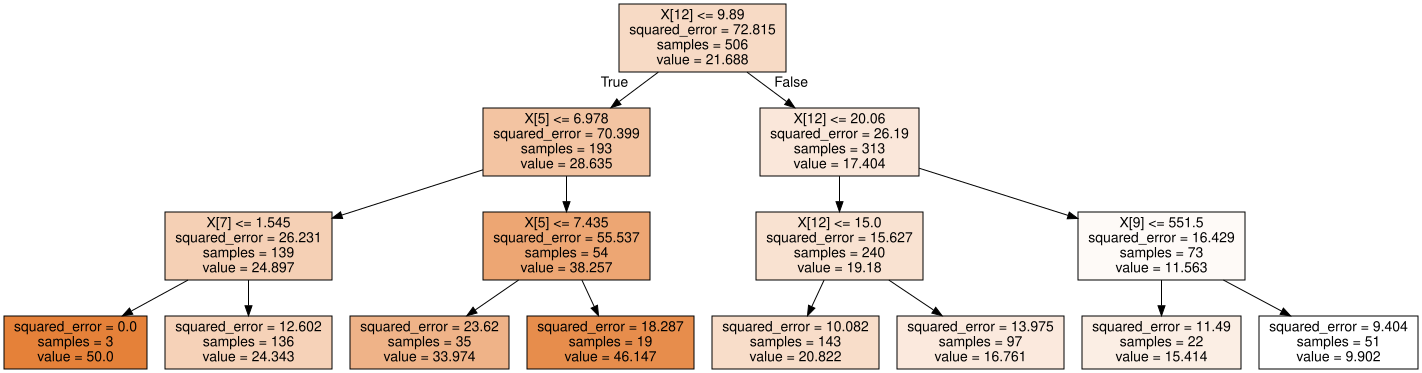

In [73]:
dot_data = tree.export_graphviz(ada[0],filled=True)
graph = graphviz.Source(dot_data)
graph

#### 第一棵回归树

In [76]:
w1 = np.full(shape = 506,fill_value=1/506)
y1_ = ada[0].predict(X)

# 计算预测值和目标值的误差
error_vector = np.abs(y1_ - y)
error_max = error_vector.max()
if error_max != 0:
    error_vector /= error_max # 归一化0~1

# 计算算法误差
estimator_error = (w1 * error_vector).sum()
print('第一棵树误差：',estimator_error)
print('算法误差：',ada.estimator_errors_)

# 计算算法权重
beta = estimator_error / (1. - estimator_error)
estimator_weight =  np.log(1. / beta)
print('第一棵树权重：',estimator_weight)
print('算法权重：', ada.estimator_weights_)

# 根据第一棵树更新权重
w2 = w1 * np.power(beta, (1. - error_vector))
w2 /= w2.sum()
# 输出
# '''
# 第一棵树误差： 0.11315306016068988
# 算法误差： [0.11315306 0.11657419 0.18593167]
# 第一棵树权重： 2.0589309911688427
# 算法权重： [2.05893099 2.02527945 1.47666508]
# '''

第一棵树误差： 0.11795413808629285
算法误差： [0.11795414 0.13086652 0.12782854]
第一棵树权重： 2.0119481636575234
算法权重： [2.01194816 1.89331886 1.9202962 ]
